<a href="https://colab.research.google.com/github/ethannaegele/stats531-midterm/blob/main/midterm_project_exploratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [120]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 39.1 MB/s eta 0:00:00


In [121]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from arch import arch_model

In [103]:
data = pd.read_csv("DAX_2010-2020.csv") # replace with path when working locally

In [38]:
data.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,12/30/2020,"13,718.78","13,750.99","13,797.09","13,717.47",28.32M,-0.31%
1,12/29/2020,"13,761.38","13,873.35","13,903.11","13,747.08",43.16M,-0.21%
2,12/28/2020,"13,790.29","13,779.05","13,818.65","13,740.21",49.25M,1.49%
3,12/23/2020,"13,587.23","13,456.63","13,601.71","13,456.63",48.73M,1.26%
4,12/22/2020,"13,418.11","13,311.02","13,441.59","13,310.42",54.62M,1.30%


In [104]:
# Clean date
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%Y')
data = data.sort_values('Date')

data.set_index('Date', inplace=True)
data = data.asfreq('B')  # Business day frequency
data['Open'] = data['Open'].ffill()


In [39]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')

In [105]:
df = data[['Open']]
df["Open"] = df["Open"].str.replace(",", "", regex=False).astype(float) # remove undesirable comma formatting in the price
df.head()

/tmp/ipython-input-2011223197.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Open"] = df["Open"].str.replace(",", "", regex=False).astype(float) # remove undesirable comma formatting in the price


,Open
Date,
2010-01-04,5975.52
2010-01-05,6043.94
2010-01-06,6032.39
2010-01-07,6016.80
2010-01-08,6028.62


In [106]:
model_202 = SARIMAX(df, order=(2, 0, 2), trend='c').fit()
print(model_202.summary())

                               SARIMAX Results                                
Dep. Variable:                   Open   No. Observations:                 2868
Model:               SARIMAX(2, 0, 2)   Log Likelihood              -17823.123
Date:                Fri, 13 Feb 2026   AIC                          35658.246
Time:                        05:01:07   BIC                          35694.014
Sample:                    01-04-2010   HQIC                         35671.141
                         - 12-30-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     14.7212      7.973      1.846      0.065      -0.906      30.348
ar.L1          1.2597      0.243      5.177      0.000       0.783       1.737
ar.L2         -0.2612      0.243     -1.075      0.2

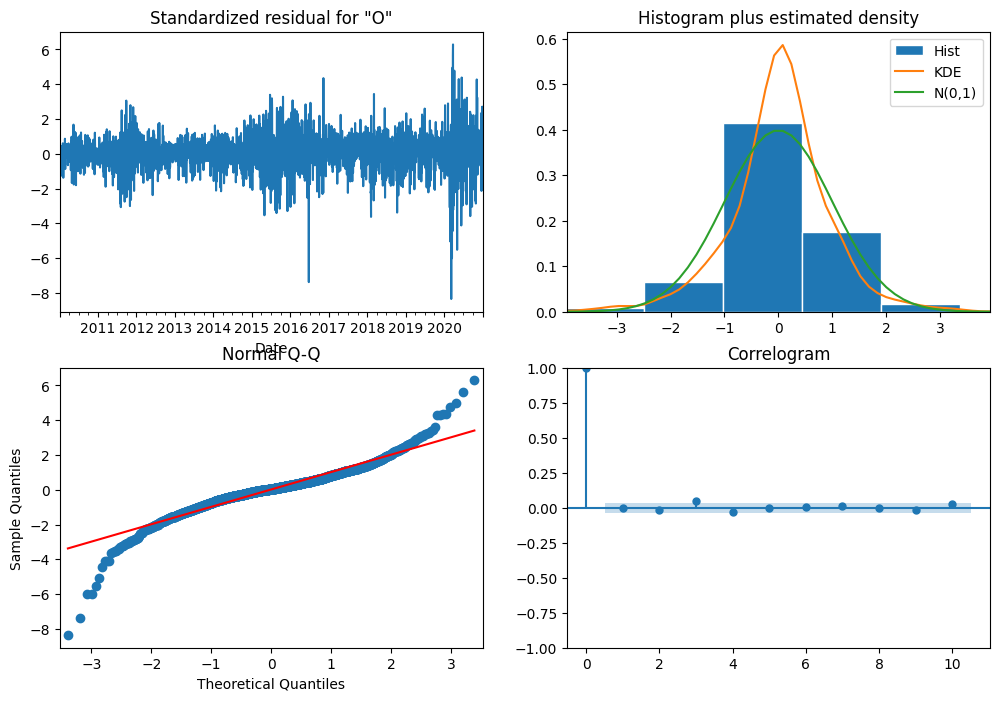

In [107]:
fig = model_202.plot_diagnostics(figsize = (12, 8))

In [108]:
preds = model_202.predict()
preds

,predicted_mean
Date,
2010-01-04,10071.076558
2010-01-05,5982.803772
2010-01-06,6051.163502
2010-01-07,6042.673192
2010-01-08,6024.643095
...,...
2020-12-24,13443.973995
2020-12-25,13455.025792
2020-12-28,13451.781135


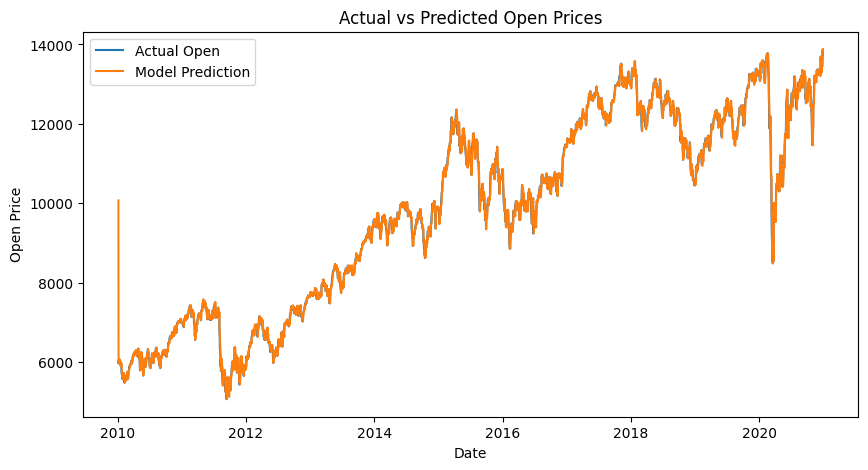

In [109]:
# Create plot
plt.figure(figsize=(10, 5))

plt.plot(df.index, df['Open'], label='Actual Open')
plt.plot(df.index, preds, label='Model Prediction')

plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('Actual vs Predicted Open Prices')
plt.legend()

plt.show()

In [110]:
preds

,predicted_mean
Date,
2010-01-04,10071.076558
2010-01-05,5982.803772
2010-01-06,6051.163502
2010-01-07,6042.673192
2010-01-08,6024.643095
...,...
2020-12-24,13443.973995
2020-12-25,13455.025792
2020-12-28,13451.781135


In [61]:
residuals = np.array(df['Open']) - np.array(preds)
residuals = residuals[1:] # ignore first term because of initialization junk
print(np.max(residuals))
print(np.percentile(residuals, 25))
print(np.percentile(residuals, 50))
print(np.percentile(residuals, 75))
print(np.mean(residuals))

988.1495576680427
-64.2903504183023
-9.019685305656822
50.12634883243663
-2.814918962975544


ARMA(2, 2) visually looks quite good in the plot.
Some notes:
- this is in sample predictions.
- we can see based on the ACF that the data should be differenced - stationarity is being violated

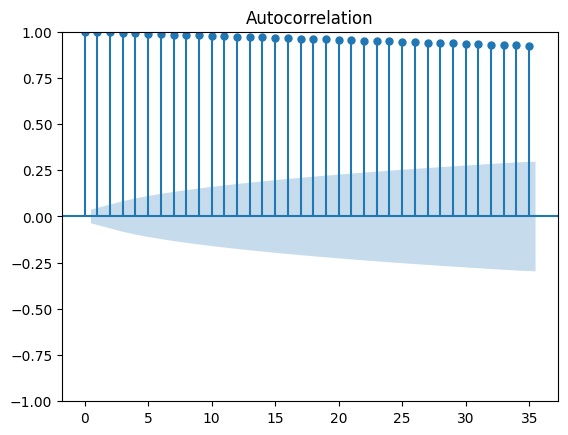

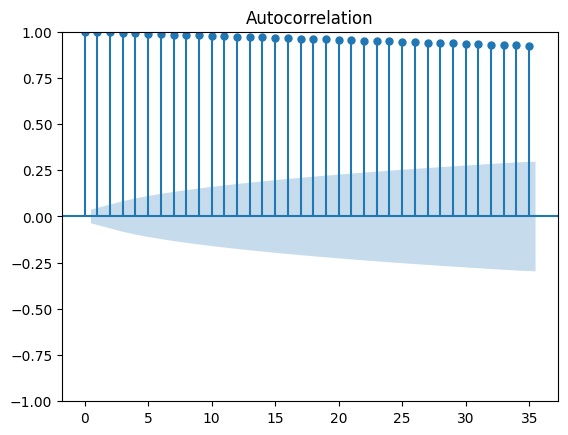

In [62]:
plot_acf(df['Open'])

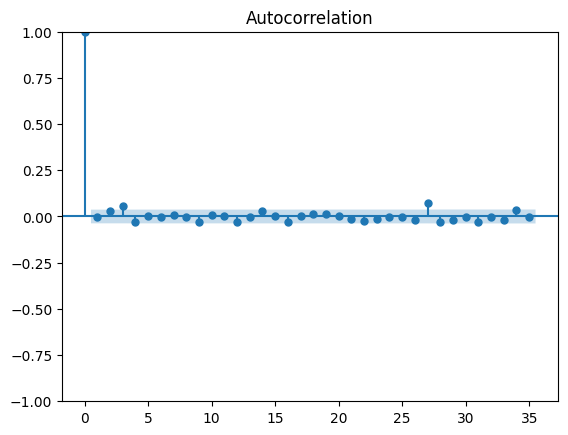

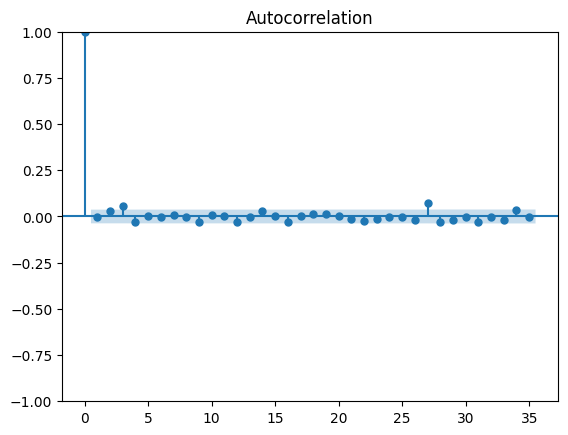

In [64]:
plot_acf(df['Open'].diff().dropna())

In [127]:
# this code is adapted from Lecture 5
def aic_table(data, P, Q, d=0, model_type='sarimax', dist='normal'):
    table = np.zeros((P+1, Q+1))
    model_type = model_type.strip().lower()
    for p in range(P+1):
        for q in range(Q+1):
            try:
                if model_type == 'sarimax':
                    model = SARIMAX(data, trend = 'c', order=(p, d, q))
                if model_type == 'garch':
                    model = arch_model(data,
                                       vol='GARCH',
                                       p=p,
                                       q=q,
                                       dist=dist)
                else:
                    raise ValueError
                results = model.fit()
                table[p, q] = results.aic # sarimax has aic attribute
            except:
                table[p, q] = np.nan
    if model_type == 'sarimax':
        df = pd.DataFrame(table,
            index=[f'AR{p}' for p in range(P+1)],
            columns=[f'MA{q}' for q in range(Q+1)])
    if model_type == 'garch':
        df = pd.DataFrame(table,
            index=[f'ARCH{p}' for p in range(P+1)], # by this, I mean there are is dependence on the p previous epsilon values
            columns=[f'GARCH{q}' for q in range(Q+1)]) # by this, I mean there are q "GARCH" terms in that there is dependence on the q previous sigma^2 values
    else:
        raise ValueError
    return df

In [66]:
aic_table(df, 3, 3)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

,MA0,MA1,MA2,MA3
AR0,51448.954191,48196.663366,44831.572274,44325.697429
AR1,34762.805961,34764.788390,34764.036458,34755.894506
AR2,34764.809022,34765.040531,34764.013217,34755.685999
AR3,34764.338737,34768.598299,34761.358371,34757.447272


In [72]:
def get_metrics(y_true, y_pred):
    metrics = {'Mean Absolute Percentage Error': mean_absolute_percentage_error(y_true=y_true, y_pred=y_pred),
               'Mean Absolute Error': mean_absolute_error(y_true=y_true, y_pred=y_pred),
               'Mean Squared Error': mean_squared_error(y_true=y_true, y_pred=y_pred)}
    return metrics

In [73]:
get_metrics(df['Open'], preds)


{'Mean Absolute Percentage Error': 0.009131812108646846,
 'Mean Absolute Error': 86.44904309255745,
 'Mean Squared Error': 20311.255854289604}

In [75]:
model_103 = SARIMAX(df, order=(1, 0, 3), trend = 'c').fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [76]:
preds_103 = model_103.predict()
get_metrics(df['Open'], preds_103)

{'Mean Absolute Percentage Error': 0.009108145949811366,
 'Mean Absolute Error': 86.29617915543089,
 'Mean Squared Error': 20370.382186364972}

In [115]:
df2 = np.log(df['Open'])

In [116]:
df2

,Open
Date,
2010-01-04,8.695426
2010-01-05,8.706811
2010-01-06,8.704899
2010-01-07,8.702311
2010-01-08,8.704273
...,...
2020-12-24,9.507227
2020-12-25,9.507227
2020-12-28,9.530905


<Figure size 640x480 with 0 Axes>

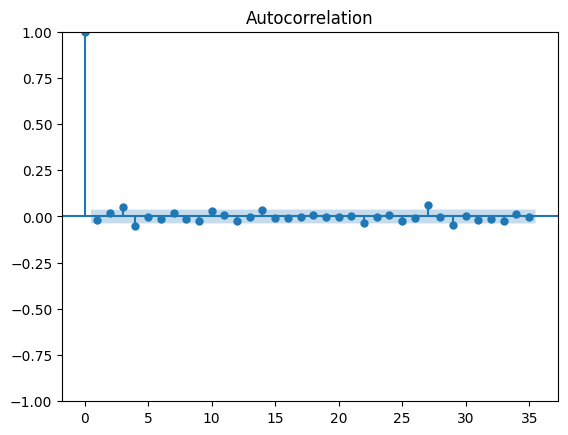

In [92]:
plt.clf()
plot_acf(df2.diff().dropna())
plt.show()

In [117]:
df2 = df2.diff().dropna()
df2.head()

,Open
Date,
2010-01-05,0.011385
2010-01-06,-0.001913
2010-01-07,-0.002588
2010-01-08,0.001963
2010-01-11,0.004850


In [118]:
df2 = df2 * 100 # percent returns, to give a more favorable scaling
df2.head()

,Open
Date,
2010-01-05,1.138499
2010-01-06,-0.191283
2010-01-07,-0.258773
2010-01-08,0.196257
2010-01-11,0.485003


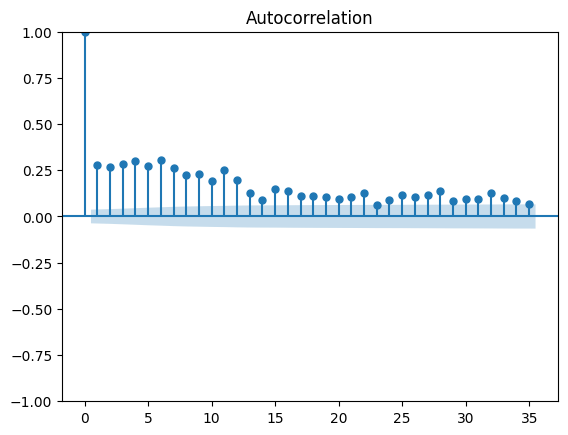

<Figure size 640x480 with 0 Axes>

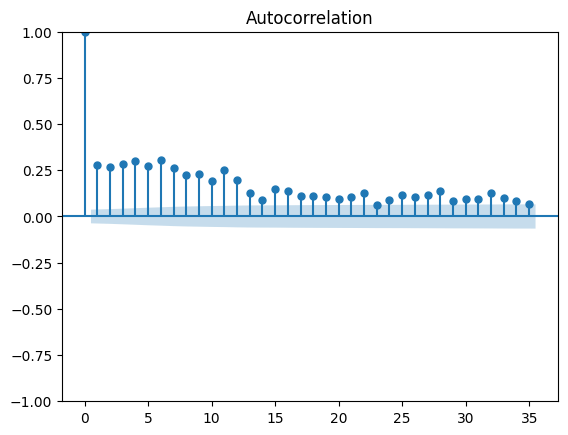

In [101]:
plt.clf()
plot_acf(df2)

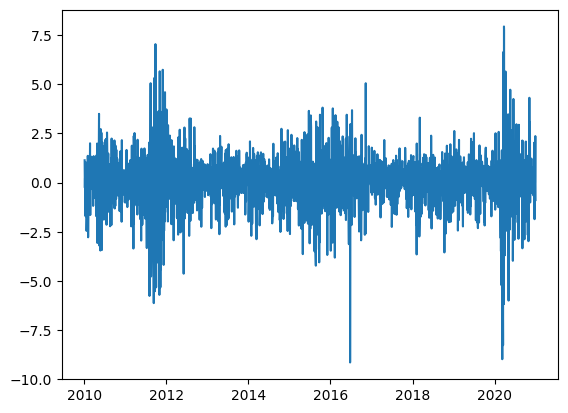

In [123]:
plt.clf()
plt.plot(df2.index, df2)
plt.show()

the above plot shows that the log returns are roughly mean 0, with sporadic periods of high variance.

GARCH model attempt using $log(P_t) - log(P_{t-1})$ as the data points



In [128]:
aic_table(df2, P = 4, Q = 4, model_type='garch')

Iteration:      1,   Func. Count:      5,   Neg. LLF: 16904.443688409367
Iteration:      2,   Func. Count:     13,   Neg. LLF: 7955.954987180561
Iteration:      3,   Func. Count:     21,   Neg. LLF: 4782.074917307355
Iteration:      4,   Func. Count:     26,   Neg. LLF: 4684.661425305523
Iteration:      5,   Func. Count:     31,   Neg. LLF: 4644.415134374505
Iteration:      6,   Func. Count:     35,   Neg. LLF: 4644.391232767392
Iteration:      7,   Func. Count:     39,   Neg. LLF: 4644.387447437297
Iteration:      8,   Func. Count:     43,   Neg. LLF: 4644.387433337963
Iteration:      9,   Func. Count:     46,   Neg. LLF: 4644.387433337768
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4644.387433337963
            Iterations: 9
            Function evaluations: 46
            Gradient evaluations: 9
Iteration:      1,   Func. Count:      6,   Neg. LLF: 17263815197549.562
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1577243.154633840

,GARCH0,GARCH1,GARCH2,GARCH3,GARCH4
ARCH0,NaN,NaN,NaN,NaN,NaN
ARCH1,9294.774867,8682.948857,8684.948857,8686.948857,8688.948857
ARCH2,9125.912528,8682.765894,8684.728912,8686.365727,8688.200686
ARCH3,8948.571509,8684.765894,8686.616074,8682.523011,8684.305603
ARCH4,8856.833648,8686.765894,8688.616073,8684.523011,8686.305603


In [130]:
model_g11 = arch_model(df2,
                        vol='GARCH',
                        p=1,
                        q=1).fit()
print(model_g11.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 17263815197549.562
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1577243.1546338405
Iteration:      3,   Func. Count:     23,   Neg. LLF: 4371.522593430719
Iteration:      4,   Func. Count:     29,   Neg. LLF: 4342.291774531097
Iteration:      5,   Func. Count:     35,   Neg. LLF: 4377.813271371599
Iteration:      6,   Func. Count:     41,   Neg. LLF: 4337.494352426509
Iteration:      7,   Func. Count:     47,   Neg. LLF: 4337.474998314821
Iteration:      8,   Func. Count:     52,   Neg. LLF: 4337.474531183009
Iteration:      9,   Func. Count:     57,   Neg. LLF: 4337.474440983514
Iteration:     10,   Func. Count:     62,   Neg. LLF: 4337.474428581527
Iteration:     11,   Func. Count:     66,   Neg. LLF: 4337.474428581163
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4337.474428581527
            Iterations: 11
            Function evaluations: 66
            Gradient evaluations: 

In [134]:
estimated_vol = model_g11.conditional_volatility
estimated_vol

,cond_vol
Date,
2010-01-05,1.072556
2010-01-06,1.077216
2010-01-07,1.031372
2010-01-08,0.990736
2010-01-11,0.948882
...,...
2020-12-24,1.091564
2020-12-25,1.041908
2020-12-28,0.995707


In [133]:
# credit to https://blog.quantinsti.com/garch-gjr-garch-volatility-forecasting-python/ for this suggestion
realized_vol = df2.rolling(window=5).std()  # 5-day window for smoothing
realized_vol

,Open
Date,
2010-01-05,NaN
2010-01-06,NaN
2010-01-07,NaN
2010-01-08,NaN
2010-01-11,0.569706
...,...
2020-12-24,1.067919
2020-12-25,1.079493
2020-12-28,1.187975


<Figure size 640x480 with 0 Axes>

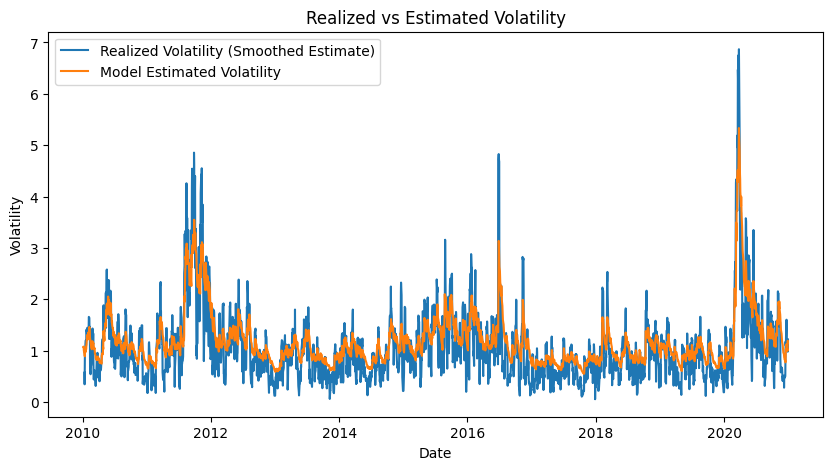

In [135]:
plt.clf()
plt.figure(figsize=(10, 5))

plt.plot(df2.index, realized_vol, label='Realized Volatility (Smoothed Estimate)')
plt.plot(df2.index, estimated_vol, label='Model Estimated Volatility')

plt.xlabel('Date')
plt.ylabel('Volatility')
plt.title('Realized vs Estimated Volatility')
plt.legend()

plt.show()

In [138]:
get_metrics(realized_vol[4:], estimated_vol[4:])

{'Mean Absolute Percentage Error': 0.49299790763114454,
 'Mean Absolute Error': 0.31854513966614983,
 'Mean Squared Error': 0.17930388822604543}

MAPE probably not worth mentioning because the numbers are pretty small to begin with; probably just pay attention to MAE, MSE, RMSE, etc.